# Visualizing ADAPT GPT results

In [18]:
import pandas as pd
import numpy as np
import json
from matplotlib import pyplot as plt

In [21]:
adapt_gpt_out_w_energies_list = json.load(
    open('data/adapt_gpt_n12_090724_d2_out_jl.json')
)

In [22]:
adapt_gpt_out_w_energies_df = pd.DataFrame(adapt_gpt_out_w_energies_list).dropna()

In [73]:
adapt_gpt_out_w_energies_df['n_edges'] = (
    adapt_gpt_out_w_energies_df['graph_w_jl'].apply(len)
)

In [74]:
len(adapt_gpt_out_w_energies_df)

300

In [75]:
adapt_gpt_out_w_energies_df[:3]

,adapt_circuit,energy_mqlib,adapt_gpt_energies,graph_w_jl,ADAPT_energy_round,q_circuits,graph,adapt_full_ar,graph_prefix,n_edges,best_adapt_gpt_ar,adapt_full_round_ar,adapt_gpt_avg_circ_len,adapt_jl_circ_len,avg_adapt_gpt_ar
0,"[new_layer_p, 276, -0.79, -0.0, new_layer_p, 2...",-20.29,"[-20.28877838629751, -20.288825597572924, -20....","[[1, 2, 0.11], [1, 3, 0.76], [2, 3, 0.94], [1,...",-20.288668,"[[new_layer_p, 277, -0.79, 0.0, new_layer_p, 2...","[[1, 2], 0.11, [1, 3], 0.76, [2, 3], 0.94, [1,...",1.0,n_12_worker_unknown_pid_1233158_ts_24-09-09__0...,37,0.999947,0.999934,11.0,11.0,0.999943
1,"[new_layer_p, 152, -0.79, 0.0, new_layer_p, 14...",-15.63,"[-15.62926519373164, -15.629333587389421, -15....","[[1, 3, 0.4], [3, 5, 0.15], [4, 5, 0.75], [4, ...",-15.629157,"[[new_layer_p, 152, -0.79, 0.0, new_layer_p, 1...","[[1, 3], 0.4, [3, 5], 0.15, [4, 5], 0.75, [4, ...",1.0,n_12_worker_unknown_pid_1233167_ts_24-09-09__0...,30,0.999959,0.999946,11.0,11.0,0.999955
2,"[new_layer_p, 48, -0.79, -0.0, new_layer_p, 25...",-16.52,"[-16.519102996763714, -16.51907123909949, -16....","[[1, 2, 0.58], [2, 3, 0.76], [1, 4, 0.67], [3,...",-16.518992,"[[new_layer_p, 48, -0.79, 0.0, new_layer_p, 25...","[[1, 2], 0.58, [2, 3], 0.76, [1, 4], 0.67, [3,...",1.0,n_12_worker_unknown_pid_1258282_ts_24-09-10__1...,31,0.999948,0.999939,11.0,11.0,0.999944


In [27]:
adapt_gpt_out_w_energies_df['best_adapt_gpt_ar'] = adapt_gpt_out_w_energies_df.apply(
    lambda x: max([
        el/x['energy_mqlib'] for el in x['adapt_gpt_energies']
    ]),
    axis=1
)

In [54]:
adapt_gpt_out_w_energies_df['avg_adapt_gpt_ar'] = adapt_gpt_out_w_energies_df.apply(
    lambda x: np.mean([
        el/x['energy_mqlib'] for el in x['adapt_gpt_energies']
    ]),
    axis=1
)

In [49]:
adapt_gpt_out_w_energies_df['adapt_gpt_avg_circ_len'] = adapt_gpt_out_w_energies_df['q_circuits'].apply(
    lambda x: np.mean([len(l) for l in x]) / 4
)

In [50]:
adapt_gpt_out_w_energies_df['adapt_jl_circ_len'] = (
    adapt_gpt_out_w_energies_df['adapt_circuit'].apply(len) / 4
)

## Visualizing results (ADAPT GPT vs. ADAPT.jl)

Text(0.5, 1.0, 'Avg approx ratio (ar) vs number of edges, n=300 graphs')

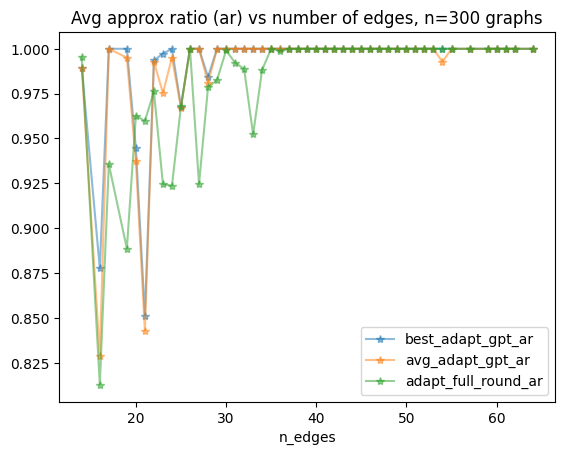

In [81]:
adapt_gpt_out_w_energies_df[
    ['n_edges', 'best_adapt_gpt_ar', 'avg_adapt_gpt_ar', 'adapt_full_round_ar',
    ]
].groupby('n_edges').agg('mean').plot(style='*-', alpha=0.5)
plt.title(
    f'Avg approx ratio (ar) vs number of edges, n={len(adapt_gpt_out_w_energies_df)} graphs'
)

In [51]:
adapt_gpt_out_w_energies_df[['adapt_jl_circ_len', 'adapt_gpt_avg_circ_len']].mean()

adapt_jl_circ_len         11.206667
adapt_gpt_avg_circ_len    10.944667
dtype: float64

In [52]:
adapt_gpt_out_w_energies_df['adapt_full_round_ar'] = adapt_gpt_out_w_energies_df.apply(
    lambda x: x['ADAPT_energy_round'] / x['energy_mqlib'],
    axis=1
)

In [55]:
adapt_gpt_out_w_energies_df[['best_adapt_gpt_ar', 'avg_adapt_gpt_ar', 'adapt_full_round_ar']].mean()

best_adapt_gpt_ar      0.996182
avg_adapt_gpt_ar       0.994881
adapt_full_round_ar    0.987985
dtype: float64